# 05 — Constructeur du dataset de Phase 2 : produit cartésien Scenarii × taxonomie

**EPIC #10355** — FallacyDetection, Phase 2, tranche A (issue #17578). Les notebooks 01 à 04 ont cartographié la taxonomie Argumentum et les datasets existants. La Phase 2 fabrique le matériau d'entraînement, et le cadrage owner du 2026-08-22 en fixe l'unité :

> « Pour son Fine-tuning + Posttraining, CoursIA a besoin de tout le matériel, toute les taxonomies en entier (pas juste les cartes), ainsi que tous les scenarii pour faire le produit cartésien et produire un dataset volumineux et équilibré. »

L'unité est donc une **paire** (scénario, nœud) : un sophisme ou une vertu de la taxonomie, placé dans une mise en situation du jeu Argumentum. Ce notebook ne génère **aucun texte**. Il décide **quelles** paires entrent dans le dataset, **dans quel split**, et rend la **consigne** qu'un LLM enseignant recevra à la tranche B. Trois décisions y sont mesurées :

1. **l'équilibrage** entre familles et entre nœuds (section 3) ;
2. **l'étanchéité** des splits : un scénario de test n'est jamais vu à l'entraînement (sections 4 et 5) ;
3. **l'anti-circularité** : la consigne ne transmet jamais un exemple de la taxonomie (section 6).

Le code vit dans `scripts/fallacy_detection/cartesian_dataset_builder.py`, couvert par `scripts/fallacy_detection/tests/test_cartesian_dataset_builder.py` ; le notebook l'appelle et commente ce qu'il mesure.

| Section | Question |
|---|---|
| 1 | Que contiennent les trois sources ? |
| 2 | Pourquoi ne pas prendre tout le produit cartésien ? |
| 3 | Comment répartir le budget entre familles et nœuds ? |
| 4 | Comment découper les scénarios ? |
| 5 | Les paires tiennent-elles leurs promesses ? |
| 6 | Que reçoit le LLM enseignant ? |
| 7 | Qu'est-ce qui est écrit, et comment le rejouer ? |
| 8 | Exercices |

**Prérequis** : notebooks 01 (taxonomie) et 04 (matrice de couverture). Exécution : quelques secondes, sans GPU ni clé d'API.

## 1. Les trois sources

Les taxonomies des sophismes et des vertus sont les copies verbatim déjà utilisées par la série `SymbolicAI/Argument_Analysis`. Le paquet Scenarii est recopié octet pour octet depuis le dépôt `ArgumentumGames/Argumentum` dans `data/argumentum_scenarii_cards.csv` ; sa provenance et sa licence sont dans `data/NOTICE-SCENARII`. `load_scenarios` recalcule le SHA1 de blob Git de la copie et refuse de charger une copie qui aurait divergé de l'amont : une copie « presque verbatim » est le piège qui a déjà fait dériver les taxonomies pendant sept semaines.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Racine du depot, robuste au repertoire de lancement (papermill, Jupyter, racine).
_here = Path.cwd().resolve()
REPO = next(p for p in (_here, *_here.parents)
            if (p / "scripts/fallacy_detection/cartesian_dataset_builder.py").is_file())
sys.path.insert(0, str(REPO / "scripts"))
from fallacy_detection import cartesian_dataset_builder as B  # noqa: E402

fallacies = B.load_fallacies()
virtues = B.load_virtues()
scenarios = B.load_scenarios()          # verifie le SHA1 de blob de la copie
nodes = fallacies + virtues

for name, path in (("sophismes", B.DEFAULT_FALLACIES), ("vertus", B.DEFAULT_VIRTUES),
                   ("scenarii", B.DEFAULT_SCENARII)):
    print(f"{name:9s} {path.relative_to(REPO).as_posix()}  blob {B.git_blob_sha1(path)[:12]}")
print()
for label, sub in (("sophismes", fallacies), ("vertus", virtues)):
    fam = Counter(n.family for n in sub)
    leaves = sum(n.is_leaf for n in sub)
    print(f"{label} : {len(sub)} noeuds hors racine, {leaves} feuilles, {len(fam)} familles, "
          f"r = {max(fam.values())}/{min(fam.values())} = {max(fam.values()) / min(fam.values()):.2f}")
    for f, n in fam.most_common():
        print(f"   {n:4d}  {f}")
cat = Counter(s.category for s in scenarios)
print(f"\nscenarii : {len(scenarios)} en {len(cat)} categories (colonne `category`, anglais)")
for c, n in cat.most_common():
    print(f"   {n:4d}  {c}")

sophismes MyIA.AI.Notebooks/SymbolicAI/Argument_Analysis/data/argumentum_fallacies_taxonomy.csv  blob 4ac3f12eaf15
vertus    MyIA.AI.Notebooks/SymbolicAI/Argument_Analysis/data/argumentum_virtues_taxonomy.csv  blob 9ff35b599e3e
scenarii  MyIA.AI.Notebooks/GenAI/FallacyDetection/data/argumentum_scenarii_cards.csv  blob 9f20eb808a1d

sophismes : 1407 noeuds hors racine, 894 feuilles, 7 familles, r = 420/89 = 4.72
    420  Influence
    394  Tricherie
    174  Insuffisance
    126  Obstruction
    102  Erreur mathématique
    102  Erreur de raisonnement
     89  Abus de langage
vertus : 222 noeuds hors racine, 139 feuilles, 7 familles, r = 55/18 = 3.06
     55  Inférence maîtrisée
     44  Échange enrichissant
     33  Argument pertinent
     27  Honnêteté intellectuelle
     25  Présentation intègre
     20  Sens quantitatif
     18  Justesse lexicale

scenarii : 167 en 7 categories (colonne `category`, anglais)
     36  Intimate relations
     30  Professional life
     27  Mythology
  

**Lecture des sources.** 1 407 sophismes et 222 vertus hors racine, soit 1 629 étiquettes possibles. Les deux taxonomies sont profondes : 894 des 1 407 nœuds de sophismes (64 %) sont des feuilles, les 513 autres regroupent des variantes. On garde ces nœuds internes, parce que le gate de Phase 3 évalue aussi la classification à la branche et qu'un nœud comme « Généralisation abusive » est une étiquette légitime même quand il a des enfants.

Le chiffre qui commande toute la suite est le rapport $r$ entre la plus grande et la plus petite famille : $420/89 = 4{,}72$ pour les sophismes (`Influence` contre `Abus de langage`), $55/18 = 3{,}06$ pour les vertus. Une taxonomie n'est pas un jeu de classes équilibré : elle reflète la richesse du vocabulaire critique, bien plus fourni pour la manipulation (`Influence`, `Tricherie`) que pour les fautes de vocabulaire.

Côté scénarios, 167 mises en situation en 7 catégories, de 36 (`Intimate relations`) à 14 (`Politics`). Les catégories servent à stratifier le découpage (section 4) ; elles ne sont pas des étiquettes du dataset.

## 2. Le produit cartésien complet

Le cadrage demande le produit cartésien. Le calculer en entier est immédiat ; la question est de savoir si on peut s'en servir tel quel comme dataset, ou en tirer un sous-ensemble au hasard.

In [2]:
S = len(scenarios)
full = {n.key: S for n in nodes}   # le produit cartesien complet : chaque noeud x chaque scenario
print(f"produit complet : {len(nodes)} noeuds x {S} scenarii = {len(nodes) * S:,} paires".replace(",", " "))
for label, sub in (("sophismes", fallacies), ("vertus", virtues)):
    im = B.imbalance(sub, full)
    part = sum(full[n.key] for n in sub) / sum(full.values())
    print(f"  {label:9s} : {sum(full[n.key] for n in sub):7d} paires ({part:.1%}), "
          f"desequilibre familles {im['family_ratio']:.2f}, noeuds {im['node_ratio']:.2f}")

# Tirer 14 000 paires uniformement dans ce produit reproduit le meme desequilibre.
rng = np.random.default_rng(0)
tirage = rng.choice(len(nodes), size=14_000, replace=True)
fam_tirage = Counter(nodes[i].family for i in tirage if nodes[i].polarity == "fallacy")
print(f"\n14 000 paires tirees uniformement : famille la plus servie / la moins servie = "
      f"{max(fam_tirage.values())}/{min(fam_tirage.values())} = "
      f"{max(fam_tirage.values()) / min(fam_tirage.values()):.2f} (sophismes)")

produit complet : 1629 noeuds x 167 scenarii = 272 043 paires
  sophismes :  234969 paires (86.4%), desequilibre familles 4.72, noeuds 1.00
  vertus    :   37074 paires (13.6%), desequilibre familles 3.06, noeuds 1.00

14 000 paires tirees uniformement : famille la plus servie / la moins servie = 3598/744 = 4.84 (sophismes)


**Lecture du produit complet.** $1\,629 \times 167 = 272\,043$ paires. C'est trop pour les faire toutes écrire par un LLM à la tranche B — à quelques centaines de tokens par texte, de l'ordre de $10^8$ tokens pour une seule langue — et c'est surtout mal équilibré. Dans le produit complet, chaque nœud reçoit exactement 167 paires : le déséquilibre **entre nœuds** est nul (1,00), mais le déséquilibre **entre familles** reproduit exactement leur taille (4,72 pour les sophismes, 3,06 pour les vertus), et les vertus ne pèsent que 13,6 % du total.

Tirer un sous-ensemble uniformément ne corrige rien : sur 14 000 paires tirées au hasard, la famille la plus servie en reçoit 4,84 fois plus que la moins servie — le même rapport, bruité. Il faut donc **choisir** le sous-ensemble, pas l'échantillonner.

## 3. Où placer le déséquilibre : la frontière $\alpha$

On donne à chaque nœud un poids qui dépend de la taille $n_f$ de sa famille : $w = n_f^{-\alpha}$. Le total d'une famille vaut alors $n_f \cdot n_f^{-\alpha} = n_f^{1-\alpha}$ (à une constante près), et le quota d'un nœud $n_f^{-\alpha}$. Avec $r = n_{\max} / n_{\min}$ :

$$\text{familles} : r^{1-\alpha}, \qquad \text{nœuds} : r^{\alpha}, \qquad \text{produit} : r^{1-\alpha} \cdot r^{\alpha} = r.$$

Le produit ne dépend pas de $\alpha$ : **on ne peut pas équilibrer à la fois les familles et les nœuds**, on choisit seulement où placer le déséquilibre. $\alpha = 0$ équilibre les nœuds et reproduit le déséquilibre des familles, comme le produit complet ; $\alpha = 1$ équilibre les familles et donne 4,7 fois plus de paires à un nœud d'`Abus de langage` qu'à un nœud d'`Influence`.

La cellule suivante compare la théorie aux quotas **entiers** réellement alloués par `allocate_counts` (plancher d'une paire par nœud, puis méthode du plus fort reste pour que le budget tombe juste).

          alpha  familles  noeuds  produit      r
sophismes  0.00      5.04    1.12     5.67   4.72
sophismes  0.25      3.08    1.57     4.83   4.72
sophismes  0.50      2.02    2.33     4.72   4.72
sophismes  0.75      1.47    3.20     4.72   4.72
sophismes  1.00      1.06    4.75     5.06   4.72
vertus     0.00      3.06    1.11     3.40   3.06
vertus     0.25      2.22    1.38     3.06   3.06
vertus     0.50      1.78    1.71     3.06   3.06
vertus     0.75      1.31    2.33     3.06   3.06
vertus     1.00      1.08    3.20     3.46   3.06


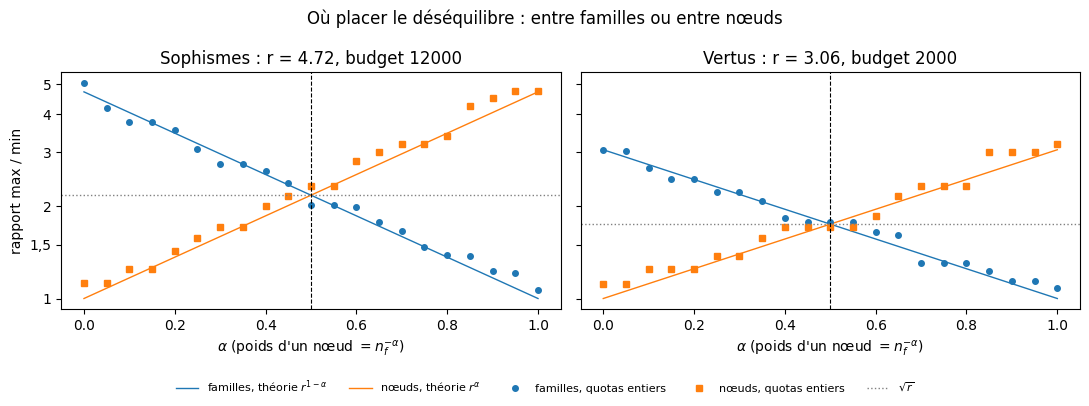

In [3]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

BUDGETS = B.DEFAULT_PARAMS["budgets"]
alphas = np.round(np.arange(0, 1.0001, 0.05), 2)
mesures = {}
for pol, sub in (("fallacy", fallacies), ("virtue", virtues)):
    rows = []
    for a in alphas:
        im = B.imbalance(sub, B.allocate_counts(sub, BUDGETS[pol], float(a)))
        rows.append((im["family_ratio"], im["node_ratio"]))
    mesures[pol] = (np.array(rows), B.imbalance(sub, {n.key: 1 for n in sub})["size_ratio"])

print(f"{'':9s} {'alpha':>5s} {'familles':>9s} {'noeuds':>7s} {'produit':>8s} {'r':>6s}")
for pol, label in (("fallacy", "sophismes"), ("virtue", "vertus")):
    rows, r = mesures[pol]
    for a in (0.0, 0.25, 0.5, 0.75, 1.0):
        fr, nr = rows[int(round(a / 0.05))]
        print(f"{label:9s} {a:5.2f} {fr:9.2f} {nr:7.2f} {fr * nr:8.2f} {r:6.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (pol, label) in zip(axes, (("fallacy", "Sophismes"), ("virtue", "Vertus"))):
    rows, r = mesures[pol]
    fine = np.linspace(0, 1, 101)
    ax.plot(fine, r ** (1 - fine), color="tab:blue", lw=1, label=r"familles, théorie $r^{1-\alpha}$")
    ax.plot(fine, r ** fine, color="tab:orange", lw=1, label=r"nœuds, théorie $r^{\alpha}$")
    ax.plot(alphas, rows[:, 0], "o", color="tab:blue", ms=4, label="familles, quotas entiers")
    ax.plot(alphas, rows[:, 1], "s", color="tab:orange", ms=4, label="nœuds, quotas entiers")
    ax.axhline(np.sqrt(r), color="grey", ls=":", lw=1, label=r"$\sqrt{r}$")
    ax.axvline(0.5, color="black", ls="--", lw=0.8)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(FixedLocator([1, 1.5, 2, 3, 4, 5]))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}".replace(".", ",")))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_title(f"{label} : r = {r:.2f}, budget {BUDGETS[pol]}")
    ax.set_xlabel(r"$\alpha$ (poids d'un nœud $= n_f^{-\alpha}$)")
axes[0].set_ylabel("rapport max / min")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=8, frameon=False)
fig.suptitle("Où placer le déséquilibre : entre familles ou entre nœuds")
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

**Lecture de la frontière.** Le produit mesuré vaut exactement $r$ à $\alpha$ = 0,5 et 0,75 pour les sophismes (4,72), et aux trois points intérieurs pour les vertus (3,06). Il s'en écarte ailleurs : 4,83 à $\alpha = 0{,}25$, 5,67 à $\alpha = 0$ et 5,06 à $\alpha = 1$ pour les sophismes. L'identité exacte demande un alignement : que la famille au plus gros total porte uniformément le plus petit quota, et la famille au plus petit total uniformément le plus grand. Les tailles se simplifient alors, et il ne reste que $n_{\max}/n_{\min}$. L'arrondi entier casse cet alignement de deux façons. À $\alpha = 0$, il donne 8 ou 9 paires aux nœuds d'une même famille, d'où un rapport de 1,12 entre nœuds au lieu de 1. À $\alpha = 0{,}25$, il donne 8 paires à 253 des 394 nœuds de `Tricherie` : cette famille dépasse alors `Influence` en total (3 011 paires contre 2 940) sans porter le plus petit quota. Sur la figure, les points entiers suivent les courbes théoriques par paliers : c'est la quantification, pas un défaut d'allocation.

Le choix par défaut est $\alpha = 0{,}5$, le point où les deux courbes se croisent à $\sqrt{r}$ ($\approx 2{,}17$ pour les sophismes, mesuré 2,02 et 2,33 une fois arrondi) : c'est lui qui minimise le pire des deux déséquilibres. La raison est le gate de Phase 3, qui évalue deux niveaux — la feuille exacte, sensible au quota par nœud, **et** la branche de premier niveau, sensible au total par famille. Favoriser un niveau au prix d'un rapport 4,7 sur l'autre dégraderait précisément la métrique qu'on n'a pas favorisée.

## 4. Des splits étanches par scénario

Un modèle qui a vu le scénario « Le Fils du tyran » à l'entraînement, habillé d'un sophisme, puis qu'on teste sur le même scénario habillé d'un autre sophisme, peut reconnaître le décor plutôt que l'argument. On découpe donc **les scénarios**, pas les paires : 70 / 15 / 15 %, stratifié par catégorie, avec au moins un scénario de validation et un de test dans chaque catégorie.

In [4]:
PARAMS = B.DEFAULT_PARAMS
scen_split = B.split_scenarios(scenarios, tuple(PARAMS["fractions"]), PARAMS["seed"])
tab = Counter((s.category, scen_split[s.path]) for s in scenarios)
print(f"{'categorie':20s} {'train':>6s} {'val':>5s} {'test':>5s}")
for c, _ in Counter(s.category for s in scenarios).most_common():
    print(f"{c:20s} {tab[(c, 'train')]:6d} {tab[(c, 'val')]:5d} {tab[(c, 'test')]:5d}")
tot = Counter(scen_split.values())
print(f"{'total':20s} {tot['train']:6d} {tot['val']:5d} {tot['test']:5d}")
print("\nexemples de scenarii de test :")
by_path = {s.path: s for s in scenarios}
for p in sorted(p for p, sp in scen_split.items() if sp == "test")[:5]:
    print(f"   {p:7s} [{by_path[p].category}] {by_path[p].title}")

categorie             train   val  test
Intimate relations       26     5     5
Professional life        22     4     4
Mythology                19     4     4
Personal life            17     4     4
Pop culture              12     3     3
History                  11     3     3
Politics                 10     2     2
total                   117    25    25

exemples de scenarii de test :
   1.2.1   [History] Joan of Arc
   1.3.2   [History] President Truman and the A-Bomb
   1.3.3   [History] Marshal here we come
   2.1.1   [Mythology] Bluebeard's wife
   2.1.10  [Mythology] The walk of shame


**Lecture du découpage.** 117 scénarios d'entraînement, 25 de validation, 25 de test, et chaque catégorie est présente dans les trois splits — y compris `Politics`, la plus petite, avec 2 scénarios de validation et 2 de test. Le prix de l'étanchéité est visible : l'évaluation ne porte que sur 25 décors, et la liste des scénarios de test dépend entièrement de la graine. Un score de test mesuré sur un seul découpage est donc un tirage parmi d'autres ; l'exercice 2 mesure à quel point ces tirages diffèrent.

## 5. Construction des paires

Chaque nœud reçoit son quota d'entraînement (section 3), réparti sur les scénarios d'entraînement en prenant à chaque fois les scénarios les moins utilisés jusque-là (égalités tranchées par la graine). Les splits d'évaluation suivent une autre règle : **chaque étiquette** y figure un nombre fixe de fois — 1 en validation, 2 en test — pour qu'aucun nœud ne manque à l'évaluation. Budgets d'entraînement : 12 000 paires pour les sophismes et 2 000 pour les vertus, un rapport de 6 proche de celui des deux taxonomies ($1\,407 / 222 = 6{,}3$).

In [5]:
pairs = B.build_pairs(nodes, scen_split, PARAMS["budgets"], PARAMS["alpha"],
                      PARAMS["val_per_node"], PARAMS["test_per_node"], PARAMS["seed"])
print("paires par split et polarite :")
for s in B.SPLITS:
    c = Counter(p.polarity for p in pairs if p.split == s)
    print(f"   {s:5s} {sum(c.values()):6d}  (sophismes {c['fallacy']}, vertus {c['virtue']})")

train_q = Counter(("F" if p.polarity == "fallacy" else "V") + str(p.node_pk)
                  for p in pairs if p.split == "train")
print(f"\nquota d'entrainement par noeud (alpha = {PARAMS['alpha']}) :")
print(f"   {'famille':26s} {'n_f':>4s} {'paires/noeud':>12s} {'total':>6s}")
for label, sub in (("sophismes", fallacies), ("vertus", virtues)):
    fam = Counter(n.family for n in sub)
    for f, n_f in fam.most_common():
        q = sorted({train_q[n.key] for n in sub if n.family == f})
        tot = sum(train_q[n.key] for n in sub if n.family == f)
        print(f"   {f:26s} {n_f:4d} {'-'.join(map(str, q)) if len(q) > 1 else q[0]:>12} {tot:6d}")
    print()

print("etancheite :", B.leak_report(pairs, nodes))
print("usage des scenarii :", B.scenario_usage(pairs))

paires par split et polarite :
   train  14000  (sophismes 12000, vertus 2000)
   val     1629  (sophismes 1407, vertus 222)
   test    3258  (sophismes 2814, vertus 444)

quota d'entrainement par noeud (alpha = 0.5) :
   famille                     n_f paires/noeud  total
   Influence                   420            6   2520
   Tricherie                   394          6-7   2456
   Insuffisance                174           10   1740
   Obstruction                 126           11   1386
   Erreur mathématique         102           13   1326
   Erreur de raisonnement      102           13   1326
   Abus de langage              89           14   1246

   Inférence maîtrisée          55            7    385
   Échange enrichissant         44            8    352
   Argument pertinent           33            9    297
   Honnêteté intellectuelle     27           10    270
   Présentation intègre         25           10    250
   Sens quantitatif             20        11-12    230
   Justess

**Lecture des paires.** 14 000 paires d'entraînement, 1 629 de validation (chaque étiquette une fois) et 3 258 de test (chaque étiquette deux fois), soit 18 887 paires : 6,9 % du produit complet. Le tableau des quotas montre l'équilibrage à l'œuvre : un nœud d'`Influence` reçoit 6 paires, un nœud d'`Abus de langage` 14, et les totaux de famille s'étagent de 2 520 à 1 246 — un rapport de 2,02 au lieu de 4,72 dans le produit complet. `Tricherie` (6-7) et `Sens quantitatif` (11-12) montrent le plus fort reste : quelques nœuds reçoivent une paire de plus pour que le budget tombe juste.

Le rapport d'étanchéité est entièrement à zéro : aucun scénario partagé entre deux splits, aucune étiquette absente d'un split, aucune paire en double. L'usage des scénarios est uniforme à une paire près dans chaque split (119-120 paires par scénario d'entraînement, 130-131 par scénario de test) : aucun décor ne domine l'apprentissage.

## 6. La consigne du LLM enseignant

À la tranche B, un LLM enseignant écrira pour chaque paire 2 à 4 phrases où un personnage commet le sophisme — ou fait preuve de la vertu — sans le nommer. La consigne suit les rôles du jeu : pour un sophisme, le baratineur parle au piocheur ; pour une vertu, c'est le piocheur qui répond au baratineur, dont la mission est de défendre une thèse intenable.

**Anti-circularité.** Le nœud n'est décrit que par son titre et sa définition, jamais par ses exemples. Sinon le modèle entraîné apprendrait à reconnaître des paraphrases des exemples de la taxonomie, et le test mesurerait la mémoire du LLM enseignant plutôt que la compréhension du sophisme. La cellule vérifie la propriété sur toutes les paires, dans les 8 langues, puis vérifie que le détecteur n'est pas aveugle.

In [6]:
texts = B.load_texts()
p_fal = next(p for p in pairs if p.split == "test" and p.polarity == "fallacy" and p.is_leaf)
p_vir = next(p for p in pairs if p.split == "test" and p.polarity == "virtue" and p.is_leaf)
for p, lang in ((p_fal, "en"), (p_fal, "fr"), (p_vir, "en")):
    print(f"--- {p.pair_id} [{lang}]")
    print(B.render_prompt(p, texts, lang))
    print()

# Controle d'anti-circularite sur toutes les paires et toutes les langues.
fuites = {lang: sum(B.prompt_contains_example(p, texts, lang) for p in pairs) for lang in B.LANGS}
print(f"prompts contenant un exemple de leur noeud ({len(pairs)} paires par langue) : {fuites}")

# Controle positif : le detecteur voit bien un exemple quand on l'injecte dans la definition.
def _avec_exemple(p):
    return any(len(e) >= 25 for e in texts["nodes"][f"F{p.node_pk}"]["en"][2])

p_sonde = next(p for p in pairs if p.polarity == "fallacy" and _avec_exemple(p))
key = f"F{p_sonde.node_pk}"
titre, _, exemples = texts["nodes"][key]["en"]
exemple = next(e for e in exemples if len(e) >= 25)
sonde = {"nodes": {**texts["nodes"], key: {**texts["nodes"][key], "en": (titre, exemple, exemples)}},
         "scenarios": texts["scenarios"]}
print(f"controle positif sur {key} (exemple injecte comme definition) :",
      B.prompt_contains_example(p_sonde, sonde, "en"))

--- test-F801-5.2.4 [en]
Scenario: The Tyrant’s Son
Context: At the edge of the galaxy, the smooth talker is a lord of the Empire who practices the arts of fear. He must convince his own son, a hero of the Resistance against the Empire, to join him.
Speaker: The Lord of the Empire. Listener: The Rebel Son.
Task: write, in English, 2 to 4 sentences said by the speaker to the listener, in which the speaker commits the fallacy "Failure to elucidate" (Using overly complex definitions that obscure rather than clarify the argument.). Do not name it and do not explain it: the reader must recognise it.

--- test-F801-5.2.4 [fr]
Scenario: Le Fils du tyran
Context: Aux confins de la galaxie, le baratineur est un seigneur de l'Empire qui pratique les arts de la peur. Il doit convaincre son propre fils, héros de la Résistance à l'Empire, de se rallier à lui.
Speaker: Le Seigneur de l'Empire. Listener: Le fils rebelle.
Task: write, in French, 2 to 4 sentences said by the speaker to the listener, in

prompts contenant un exemple de leur noeud (18887 paires par langue) : {'fr': 0, 'en': 0, 'es': 0, 'ar': 0, 'fa': 0, 'zh': 0, 'ru': 0, 'pt': 0}
controle positif sur F799 (exemple injecte comme definition) : True


**Lecture des consignes.** La paire `test-F801-5.2.4` rend la même consigne en anglais et en français : seules la langue de la réponse et les textes du scénario et du nœud changent, la structure est fixe. La vertu `V4` (« Deductive argument ») est confiée au membre du comité des Jeux — le piocheur —, qui répond au champion de ski : les rôles sont bien inversés.

Le contrôle d'anti-circularité vaut 0 dans les 8 langues, sur 18 887 paires chacune. Ce zéro n'était pas acquis. Au commit amont épinglé, la définition persane (`desc_fa`) du nœud F944 (« Sound bite ») contient la carte entière en trois lignes étiquetées nom / explication / exemple, **exemple compris** : les 9 paires de ce nœud transmettaient donc leur exemple dans la consigne persane. Le constructeur n'en garde plus que la ligne d'explication, et `load_texts` refuse désormais de charger un titre ou une définition qui contiendrait encore un exemple. Le contrôle positif confirme que le détecteur voit un exemple dès qu'on en réinjecte un : un zéro obtenu avec un détecteur aveugle ne prouverait rien.

## 7. Écriture des splits et du manifeste

Le dataset est écrit dans `data/phase2/` : trois CSV d'identifiants — pas de texte, les textes seront générés à la tranche B à partir de ces identifiants — et un `manifest.json` qui porte les paramètres, les SHA1 de blob des sources, le SHA-256 de chaque split et les rapports d'équilibre et d'étanchéité. `val.csv` et `test.csv` sont committés ; `train.csv` ne l'est pas : il se régénère à l'identique en moins d'une seconde, et c'est son SHA-256 dans le manifeste qui l'épingle.

In [7]:
import hashlib

OUT = REPO / "MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2"

# La chaine complete rejouee d'un bloc : memes paires que celles construites pas a pas ?
_, _, _, pairs_bis, manifest = B.build(PARAMS)
print("chaine complete == construction pas a pas :", pairs_bis == pairs)

paths = B.write_splits(pairs, OUT)
paths["manifest"] = B.write_manifest(manifest, OUT)
for s in B.SPLITS:
    data = paths[s].read_bytes()
    ok = hashlib.sha256(data).hexdigest() == manifest["files"][f"{s}.csv"]["sha256"]
    print(f"{paths[s].relative_to(REPO).as_posix():58s} {len(data) / 1024:6.1f} Ko "
          f"{manifest['files'][f'{s}.csv']['rows']:6d} lignes, sha256 conforme : {ok}")
print(f"{paths['manifest'].relative_to(REPO).as_posix():58s} "
      f"{paths['manifest'].stat().st_size / 1024:6.1f} Ko")
print("\nsources epinglees :")
for k, v in manifest["sources"].items():
    print(f"   {k:26s} {v}")
print("\ncolonnes :", ", ".join(B.CSV_COLUMNS))
print("premiere ligne de test.csv :", paths["test"].read_text(encoding="utf-8").splitlines()[1])

chaine complete == construction pas a pas : True
MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2/train.csv  823.3 Ko  14000 lignes, sha256 conforme : True
MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2/val.csv   88.2 Ko   1629 lignes, sha256 conforme : True
MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2/test.csv  182.7 Ko   3258 lignes, sha256 conforme : True
MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2/manifest.json    2.0 Ko

sources epinglees :
   fallacies_blob_sha1        4ac3f12eaf15fbda1de3432abbf5b57b6cb9e728
   virtues_blob_sha1          9ff35b599e3eb6ba9c2b4563bf3ff52419def1b9
   scenarii_blob_sha1         9f20eb808a1d22c9c1a5dd1b96460b0d6a23db60
   scenarii_upstream_commit   0ab05d66576a1007c3952a67e2dd1eaf8f9b502c

colonnes : pair_id, split, polarity, node_pk, family, depth, is_leaf, scenario_path
premiere ligne de test.csv : test-F798-2.2.8,test,fallacy,798,Abus de langage,1,0,2.2.8


**Lecture de l'écriture.** Rejouer la chaîne d'un bloc (`B.build`) rend exactement les mêmes paires que la construction pas à pas, et les trois fichiers ont le SHA-256 annoncé par le manifeste. C'est ce qui rend le dataset **rejouable** : les sources sont épinglées (SHA1 des deux taxonomies, SHA1 de la copie Scenarii et commit amont dont elle provient) et les paramètres sont dans le manifeste. Le test `test_real_build_matches_committed_manifest` refait ce calcul contre les fichiers committés ; le dossier `scripts/fallacy_detection/tests` n'est pas encore lancé par la CI, son câblage est suivi par #17580. Pour régénérer `train.csv` depuis la racine du dépôt :

```
python scripts/fallacy_detection/cartesian_dataset_builder.py --out MyIA.AI.Notebooks/GenAI/FallacyDetection/data/phase2
```

Chaque ligne ne porte que des identifiants : `node_pk` renvoie à la taxonomie de sa `polarity`, `scenario_path` au paquet Scenarii ; `family`, `depth` et `is_leaf` sont recopiés pour permettre les évaluations par niveau sans relire la taxonomie.

## 8. Exercices

Les trois exercices réutilisent les objets déjà en mémoire (`B`, `fallacies`, `scenarios`, `PARAMS`, `BUDGETS`, `paths`). Ils interrogent chacun une décision de la tranche A : l'invariant d'équilibrage, la stabilité du découpage, et ce que valent les références naïves sur le test.

### Exercice 1 — L'invariant à $\alpha = 0{,}3$

**Contexte.** La section 3 affirme que le produit des deux déséquilibres vaut $r$ quel que soit $\alpha$, tant que l'arrondi entier n'a pas désaligné les familles extrêmes. Vérifier l'affirmation en un point qui n'a pas été tabulé, $\alpha = 0{,}3$, et comparer chaque facteur à sa prédiction théorique ($r^{0,7}$ pour les familles, $r^{0,3}$ pour les nœuds). Si les facteurs s'écartent de la théorie, expliquer pourquoi leur produit, lui, ne s'en écarte pas.

In [8]:
# Exercice 1 - L'invariant family_ratio x node_ratio = r a alpha = 0.3
# Etape 1 : allouer le budget des sophismes a alpha = 0.3
#           (B.allocate_counts(fallacies, BUDGETS["fallacy"], 0.3))
# Etape 2 : mesurer family_ratio et node_ratio avec B.imbalance
# Etape 3 : comparer chacun a sa prediction (r ** 0.7 et r ** 0.3), puis leur produit a r
# Indice : regarder les quotas min et max, et quelles familles les portent
resultat_ex1 = None  # TODO etudiant : {"family_ratio": ..., "node_ratio": ..., "produit": ...}
print("Exercice a completer" if resultat_ex1 is None else resultat_ex1)

Exercice a completer


### Exercice 2 — Un score de test dépend-il de la graine du découpage ?

**Contexte.** Le jeu de test ne compte que 25 scénarios. Mesurer à quel point il change d'une graine à l'autre : pour les graines 0 à 9, calculer l'indice de Jaccard entre le jeu de test de chaque graine et celui de la graine 0. Puis chercher combien de graines il faut pour que chacun des 167 scénarios soit passé au moins une fois en test. Qu'en conclure pour la façon de rapporter un score à la Phase 3 ?

In [9]:
# Exercice 2 - Un score de test depend-il de la graine du decoupage ?
# Etape 1 : pour seed in range(10), recalculer
#           B.split_scenarios(scenarios, tuple(PARAMS["fractions"]), seed)
# Etape 2 : indice de Jaccard entre le jeu de test de chaque graine et celui de la graine 0
# Etape 3 : nombre de graines necessaires pour que chaque scenario ait ete au moins une fois en test
# Indice : l'etancheite (B.leak_report) reste a zero pour toutes les graines
resultat_ex2 = None  # TODO etudiant : {"jaccard": [...], "graines_pour_tout_couvrir": ...}
print("Exercice a completer" if resultat_ex2 is None else resultat_ex2)

Exercice a completer


### Exercice 3 — Les références naïves sur `test.csv`

**Contexte.** Avant d'entraîner quoi que ce soit, il faut savoir ce que vaut un classifieur qui ne regarde pas le texte. Sur `test.csv`, calculer l'exactitude d'un classifieur qui prédit toujours la famille majoritaire, puis sa macro-F1 sur les 14 familles ; l'exactitude d'un classifieur qui prédit toujours « sophisme » ; et celle d'un classifieur qui prédit toujours le même nœud (feuille exacte).

In [10]:
# Exercice 3 - Les references naives sur test.csv
# Etape 1 : relire paths["test"] avec csv.DictReader
# Etape 2 : exactitude du classifieur "toujours la famille majoritaire", puis sa macro-F1
#           sur les 14 familles
# Etape 3 : exactitude de "toujours sophisme" (polarite) et de "toujours le meme noeud"
# Indice : chaque etiquette figure deux fois en test ; comparer a la distribution de train.csv
resultat_ex3 = None  # TODO etudiant : dict des quatre references
print("Exercice a completer" if resultat_ex3 is None else resultat_ex3)

Exercice a completer


### Attendus et anti-pièges (exercices 1 à 3)

**Exercice 1 (invariant à $\alpha = 0{,}3$).** *Attendu* : un rapport familles de 2,75 et un rapport nœuds de 1,71, contre 2,96 et 1,59 prédits : chaque facteur s'écarte de la théorie d'environ 7 %, mais leur produit vaut 4,72, soit $r$ exactement. L'invariant tient dès que la plus grande famille porte uniformément le plus petit quota (7 paires par nœud d'`Influence`) et la plus petite famille le plus grand (12 par nœud d'`Abus de langage`) : $\frac{420 \times 7}{89 \times 12} \times \frac{12}{7} = \frac{420}{89}$. *Anti-piège* : conclure que l'allocation est fausse parce que les facteurs ne suivent pas $r^{0,7}$ et $r^{0,3}$. La quantification entière déplace le point le long de la frontière sans l'en faire sortir, tant que l'alignement tient ; il ne casse que lorsqu'une famille reçoit deux quotas différents et change de rang (section 3, $\alpha$ = 0 et 0,25).

**Exercice 2 (graine du découpage).** *Attendu* : l'indice de Jaccard vaut 1 pour la graine 0 elle-même et reste entre 0 et 0,11 pour les neuf autres — deux découpages ne partagent presque aucun scénario de test. Dix graines ne couvrent que 132 des 167 scénarios ; il en faut 63 pour que chacun soit passé au moins une fois en test. Conséquence pour la Phase 3 : un score mesuré sur un seul découpage est un tirage ; il faut rapporter moyenne et dispersion sur plusieurs graines de découpage, comme on le fait déjà pour les graines d'entraînement. *Anti-piège* : confondre variabilité et fuite. `leak_report` reste à zéro pour chaque graine : l'étanchéité n'est pas en cause, c'est la taille du jeu de test qui l'est.

**Exercice 3 (références naïves).** *Attendu* : la famille majoritaire du test est `Influence`, 840 lignes sur 3 258, soit 25,8 % d'exactitude, mais sa macro-F1 sur 14 familles ne vaut que 2,9 %. Prédire toujours « sophisme » donne 86,4 % d'exactitude en polarité ; prédire toujours le même nœud donne $2 / 3\,258 = 0{,}06\,\%$ en feuille exacte. *Anti-piège* : lire 25,8 % ou 86,4 % comme un plancher raisonnable. Les splits d'évaluation sont équilibrés **par nœud**, pas par famille : la distribution des familles en test reproduit leur taille, et l'exactitude y récompense le biais vers les grosses familles et vers les sophismes. Le gate de Phase 3 se lit donc en macro-moyenne, faute de quoi un modèle qui ignore les vertus afficherait 86 % en polarité. Second piège : la famille majoritaire de l'entraînement est aussi `Influence`, mais à 18 % seulement — l'équilibrage à $\alpha = 0{,}5$ a déplacé la distribution d'entraînement, pas celle du test.

## 9. Conclusion — ce que livre la tranche A, ce qu'elle laisse

La tranche A fixe le **plan d'échantillonnage** du dataset de Phase 2 sans générer un mot : 18 887 paires (scénario, nœud) choisies dans un produit cartésien de 272 043, un équilibrage à $\alpha = 0{,}5$ qui ramène le déséquilibre entre familles de 4,72 à 2,02 au prix d'un rapport 2,33 entre nœuds, des splits étanches par scénario, et une consigne qui ne transmet jamais un exemple de la taxonomie — une propriété vérifiée dans les 8 langues, et qu'un défaut de la source persane violait avant correction. Tout se rejoue depuis le manifeste.

**Ce qui reste** (EPIC #10355) :

- **Tranche B — la génération.** Un LLM enseignant auto-hébergé écrit les textes à partir des consignes de la section 6, avec un contrôle aller-retour (le texte généré est-il reclassé sur son nœud ?) et une mesure de recouvrement avec les exemples de la taxonomie.
- **Tranche C — le test externe humain.** Des corpus académiques alignés sur la taxonomie (notebook 03), après vérification de leur licence.
- **Phase 3 — le gate.** Macro-F1 au-dessus de la référence majoritaire (exercice 3) et d'une référence à règles, sur plusieurs graines d'entraînement et de découpage (exercice 2), en feuille exacte **et** en branche de premier niveau.

**Licence.** Le paquet Scenarii porte deux marques : LGPL-3.0 pour le dépôt amont, CC BY-NC-SA sur les faces de cartes. La lecture la plus stricte est appliquée (`data/NOTICE-SCENARII`) : attribution « Argumentum », usage non commercial, partage à l'identique. La colonne `CCby` doit suivre tout dataset dérivé, y compris les textes générés à la tranche B.